# FunCube+ Mode Dynamic Transponder Analysis and Simulation Model for AMSAT-UK

The proposed "fast uplink, slow downlink" dynamic transponder concept for AMSAT-UK's upcoming FunCube+ 2U CubeSat represents an interesting power-conservation strategy, but requires careful analysis of buffering requirements, timing constraints, and mode compatibility. Open Research Institute (ORI) was invited by AMSAT-UK to support and propose designs for an upcoming launch opportunity. This article is the first in a series from ORI about this collaboration. 

## Challenges

Buffer size requirements need to be calculated and tested. We must store potentially entire passes worth of data. We have latency challenges. Communication becomes store-and-forward rather than real-time. FPGA complexity is mainly in the buffering and control logic. We need to define the user experience. We need to define the Doppler on both fast receive and slow transmit.

## Mode Analysis for FunCube+

Looking at the operating context of FunCube-1 (AO-73) we have an uplink of 435.150-435.130 MHz (Mode U, 20 kHz bandwidth, LSB) and a downlink of 145.950-145.970 MHz (Mode V, USB). This is a traditional transponder with an inverting linear at 300 mW PEP. Telemetry is 145.935 MHz BPSK, 30/300 mW. What are some reasonable options for FunCube+? 

### 1) Digital Voice, Data, and Keyboard Mode
Fast Uplink of 435.xxx MHz with 81 kHz bandwidth Opulent Voice protocol. 
Slow Downlink of 145.xxx MHz with a 20 kHz bandwidth BPSK data stream. This is the current bandwidth limit.
Bandwidth is traded off against latency and satellite power budget for up to ~4:1 compression.

Open source implementation for FPGA can be found at https://github.com/OpenResearchInstitute/pluto_msk. Advantages include clear quantifiable data rates for buffering calculations and high fidelity voice integrated with keyboard chat, data, and control messages. 

### 2) Digital Data Mode or Pure Store and Forward
Fast Uplink at 435.xxx MHz with FSK/PSK at 9600 bps. Mode such as G3RUH.
Slow Downlink at 145.xxx MHz with BPSK at 1200 bps. The optimization of the rates would need to be optimized and analyzed, but we could achieve an 8:1 radio of data rate compression. 

This is relatively easy to implement in an FPGA. There are clear quantifiable data rates for buffering calculations. There is potential compatibility with FUNcube Dashboard software ecosystem. This would be suitable for telemetry and educational data collection.


```
┌─────────────────────────────────────────────────────────┐
│                    Ground Station Domain                │
│  - High Power Transmitter                               │
│  - Fast uplink mode                                     │
│  - Receives slow downlink mode                          │
└─────────────────────────────────────────────────────────┘
                        Fast UP          │
                          │          Slow DOWN
┌─────────────────────────────────────────────────────────┐
│              Satellite Transponder Domain               │
│  ┌──────────────────────────────────────────────────┐   │
│  │  RF Frontend (Mode U/V or S-band)                │   │
│  └──────────────────────────────────────────────────┘   │
│                          |                              │
│  ┌──────────────────────────────────────────────────┐   │
│  │  Demodulator (Fast Rate)                         │   │
│  │  - Doppler compensation                          │   │
│  │  - Symbol timing recovery                        │   │
│  └──────────────────────────────────────────────────┘   │
│                          |                              │
│  ┌──────────────────────────────────────────────────┐   │
│  │  FPGA Processing Domain                          │   │
│  │  ┌────────────────────────────────────────────┐  │   │
│  │  │ Rate Buffer (FIFO)                         │  │   │
│  │  │ - Elastic storage                          │  │   │
│  │  │ - Flow control                             │  │   │
│  │  └────────────────────────────────────────────┘  │   │
│  │  ┌────────────────────────────────────────────┐  │   │
│  │  │ Power Management Controller                │  │   │
│  │  │ - Battery state monitoring                 │  │   │
│  │  │ - Transmit duty cycle control              │  │   │
│  │  └────────────────────────────────────────────┘  │   │
│  └──────────────────────────────────────────────────┘   │
│                          |                              │
│  ┌──────────────────────────────────────────────────┐   │
│  │  Modulator (Slow Rate)                           │   │
│  └──────────────────────────────────────────────────┘   │
│                          |                              │
│  ┌──────────────────────────────────────────────────┐   │
│  │  RF Transmitter (Lower power)                    │   │
│  └──────────────────────────────────────────────────┘   │
└─────────────────────────────────────────────────────────┘
```

## Jupyter Lab Notebook Python Classes

Link and design analysis was carried out in a Jupyter Lab Notebook in Python. Here is an explanation of the code and the results. 

### Python imports

We import the libraries that we need to run our code. These are helpful functions for math, plots, code organization, and variable enumeration.  

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from enum import Enum

### TransponderConfig Dataclass

A dataclass is a object oriented structure. A dataclass is a collection of members (variables or constants). A dataclass is primarily used to store data. While it can contain methods, its main job is to organize related values together in a clean, simple way. This is how we configure our uplink and downlink data rates, buffer sizes, pass duration, radio parameters, battery and solar capacities, and other values. We can have a separate dataclass for different configurations. If we want to change a configuration, or try out a different proposal, then we can simply import a different dataclass that corresponds to a different design. Keeping the data separate from the calculations helps make our analysis flexible and results in easier and better documentation. 

When we want to create a TransponderConfig object, we use the dataclass name as if it was a function. It sets itself up and returns the object to the name we provide. That would look like this:

`my_config_is_called_harold = TransponderConfig()`

In order to load and run different configurations, or to compare multiple configurations, we pre-define the critical values that we are interested in. We need to supply the uplink_rate_bps and downlink_rate_bps at a minimum. The rest of the values in the dataclass have defaults. We can override any of the default values in the pre-defined configuration section. 

Think of this as going into a library to get a set of books for a homework assignment. Let's say that every time you go in to the library, you always pick up a style guide that covers the complicated format for the footnotes for that assignment, and you also get a book that has all the math functions for whatever class you're taking so you don't have to memorize them. You're going to get those two types of books every time. This is similar to having to provide the uplink and downlink data rates. 

In your backpack you have basic reference material that will do in a pinch. These are your default values. Sometimes, though, you need something different. You might need a newer reference, or you have a special case that you're working on. When you already have a decent foundational text in your backpack, but you need something that goes in to more detail, you are overriding the default. 

We could call our dataclass directly. We would need to provide, at a minimum, the uplink and downlink data rates as arguments when we create a TransponderConfig object. That would look like this:

```
config = TransponderConfig(
        uplink_rate_bps=9600,
        downlink_rate_bps=1200
        )
```

Since we want to manage a variety of configurations, we use a dictionary. A dictionary is a data structure that stores values in key value pairs. This is like a contacts list where you look up a name (key) to get a phone number (value). We use short, descriptive keys like 'opulent_voice' or 'legacy' to retrieve complete TransponderConfig object creation instructions. This is like having a recipe book. We have the ingredients and instructions for making sixteen different types of waffles. All we need to do is open it up to the right page and then start following the instructions to create our waffle. 

Using a dictionary with the command to create specific configuration objects makes managing multiple configurations much easier than writing out a separate dataclass for each one. With this pattern, we only change the key in one place. If we created a pile of separate dataclasses, we'd have to name each one individually. When we wanted to change configurations, we'd have change multiple places in the code. This is clunky and bug-prone.

Now, when we want to create an object for a particular configuration, it looks like this:

`config = CONFIGS['opulent_voice']`

The key value of the configuration goes inside the square brackets and single quotes. config becomes that specific dataclass configuration.

Another advantage of doing it this way is that we can compare multiple configurations. This will be a valuable technique for us as we will need to compare and contrast different modes to see which ones will work best with the orbit and the hardware capabilities of the FunCube+. 

```
def run_comparison(config_names):
    """Run simulation for multiple configurations and compare"""
    results = {}
    
    for name in config_names:
        config = CONFIGS[name]
        transponder = DynamicTransponder(config)
        stats = transponder.simulate_pass(pass_duration_sec=600)
        results[name] = stats
    
    # Print comparison
    print("=" * 80)
    print("CONFIGURATION COMPARISON")
    print("=" * 80)
    
    for name, stats in results.items():
        print(f"\n{CONFIGS[name].config_name}:")
        print(f"  Uplink: {CONFIGS[name].uplink_rate_bps} bps, Downlink: {CONFIGS[name].downlink_rate_bps} bps")
        print(f"  Buffer: {CONFIGS[name].buffer_size_bytes / 1024:.0f} KB")
        print(f"  Data Efficiency: {stats['data_efficiency_%']:.1f}%")
        print(f"  Data Lost: {stats['rx_lost_kb']:.2f} KB")
        print(f"  Buffer Usage: {stats['buffer_max_util_%']:.1f}%")
    
    return results

# Run comparison
results = run_comparison(['legacy', 'opulent_voice', 'balanced', 'large_buffer_opulent'])
```


In [8]:
@dataclass
class TransponderConfig:
    """Base configuration parameters for the dynamic transponder"""
    uplink_rate_bps: int
    downlink_rate_bps: int
    buffer_size_bytes: int = 65536
    pass_duration_sec: float = 600
    tx_power_watts: float = 0.3
    rx_power_watts: float = 0.1
    battery_capacity_wh: float = 10
    solar_power_watts: float = 2.5
    config_name: str = "Custom"

# We have pre-defined configurations
CONFIGS = {
    'legacy': TransponderConfig(
        uplink_rate_bps=9600,
        downlink_rate_bps=1200,
        config_name="Legacy Data Mode (G3RUH-style)"
    ),
    'opulent_voice': TransponderConfig(
        uplink_rate_bps=54200,
        downlink_rate_bps=9600,
        config_name="Opulent Voice Protocol"
    ),
    'balanced': TransponderConfig(
        uplink_rate_bps=19200,
        downlink_rate_bps=4800,
        config_name="Balanced Throughput"
    ),
    'large_buffer_opulent': TransponderConfig(
        uplink_rate_bps=54200,
        downlink_rate_bps=9600,
        buffer_size_bytes=524288,  # 512 KB
        config_name="Opulent Voice with Large Buffer"
    )
}



### TransponderMode Class

This class sets up an *enumeration* of transponder modes. We can be in receiving, buffering, transmitting, or idle state. When we call TransponderMode(number) then it returns the mode corresponding to that number, as defined inside the class. 

In [9]:
class TransponderMode(Enum):
    RECEIVING = 1
    BUFFERING = 2
    TRANSMITTING = 3
    IDLE = 4

### DynamicTransponder Class

At the heart of the simulation are the DynamicTransponder Class methods (functions). This class contains a set of methods that we are going to be using in our mode analysis. The initialization function is listed first. This function is called whenever we create a DynamicTransponder Object. A TransponderConfig object is requried in order to creat a DynamicTransponder object. When we run an analysis, we create a TransponderConfig object first, then we use that list of values to set up a Transponder object. 

Separating configuration clases from the transponder class gives us flexibility and clarity. We can look at the values in the configuration file without having to search through a lengthy class full of function defintions for variables. We can have multiple configurations and then simply re-use the DynamicTransponder class with different configurations. This division of labor is very common in scientific Python programming and is a naturally good fit for the analysis of radio systems. 

We get many of the members of the DynamicTransponder class by importing all of the members from the TransponderConfig dataclass. This is our "starter set" of values. Each value from the Configuration dataclass is then available in TransponderConfig as self.config.name-of-variable-in-TransponderConfig-dataclass. 

Right after that, we also set up additional members for the Transponder object, such as self.buffer_fill_bytes and self.time_sec. 

In [10]:
class DynamicTransponder:
    def __init__(self, config: TransponderConfig):
        self.config = config
        self.buffer_fill_bytes = 0
        self.mode = TransponderMode.IDLE
        self.battery_level_wh = config.battery_capacity_wh
        self.time_sec = 0
        
        # We have separate tracking for attempted, buffered, and lost data
        self.rx_data_total_bytes = 0       # Total attempted to receive
        self.rx_data_buffered_bytes = 0    # What actually made it into buffer
        self.rx_data_lost_bytes = 0        # What was lost to overflow
        self.tx_data_total_bytes = 0
        self.buffer_history = []
        self.battery_history = []
        self.mode_history = []

    def receive_uplink(self, duration_sec: float, duty_cycle: float = 0.5):
        # Calculate how much data is attempting to come in
        attempted_bytes = int(self.config.uplink_rate_bps / 8 * duration_sec * duty_cycle)
        
        # Track total attempted receive
        self.rx_data_total_bytes += attempted_bytes
        
        # Calculate how much actually fits in buffer
        available_space = self.config.buffer_size_bytes - self.buffer_fill_bytes
        data_bytes = min(attempted_bytes, available_space)
        
        # Track overflow
        if attempted_bytes > available_space:
            overflow = attempted_bytes - available_space
            self.rx_data_lost_bytes += overflow
            print(f"  Buffer overflow! Lost {overflow} bytes")
        
        # Only add what actually fits
        self.buffer_fill_bytes += data_bytes
        self.rx_data_buffered_bytes += data_bytes
        
        power_consumed = self.config.rx_power_watts * duration_sec / 3600
        self.battery_level_wh -= power_consumed
        
        self.mode = TransponderMode.RECEIVING

    def transmit_downlink(self, duration_sec: float):
        # Calculate how much we could transmit
        attempted_bytes = int(self.config.downlink_rate_bps / 8 * duration_sec)
        
        # Can only transmit what's in the buffer
        data_bytes = min(attempted_bytes, self.buffer_fill_bytes)
        
        self.buffer_fill_bytes -= data_bytes
        self.tx_data_total_bytes += data_bytes
        
        power_consumed = self.config.tx_power_watts * duration_sec / 3600
        self.battery_level_wh -= power_consumed
        
        self.mode = TransponderMode.TRANSMITTING

    def solar_charge(self, duration_sec: float, illumination: float = 1.0):
        power_gained = (self.config.solar_power_watts * illumination * duration_sec / 3600)
        self.battery_level_wh = min(self.battery_level_wh + power_gained, self.config.battery_capacity_wh)

    def log_state(self):
        self.buffer_history.append(self.buffer_fill_bytes)
        self.battery_history.append(self.battery_level_wh)
        self.mode_history.append(self.mode.value)

    def simulate_pass(self, pass_duration_sec: float = 600):
        timestep = 10
        
        for t in np.arange(0, pass_duration_sec, timestep):
            self.time_sec = t
            
            if t < pass_duration_sec / 2:
                self.receive_uplink(timestep, duty_cycle=0.6)
                self.solar_charge(timestep, illumination=0.5)
            else:
                if self.buffer_fill_bytes > 0:
                    self.transmit_downlink(timestep)
                else:
                    self.mode = TransponderMode.IDLE
                self.solar_charge(timestep, illumination=0.5)
            
            self.log_state()
            
        return self.get_statistics()
    
    def get_statistics(self):
        compression_ratio = self.config.uplink_rate_bps / self.config.downlink_rate_bps
        buffer_max_utilization = max(self.buffer_history) / self.config.buffer_size_bytes * 100
        data_efficiency = (self.tx_data_total_bytes / self.rx_data_total_bytes * 100) if self.rx_data_total_bytes > 0 else 0
        
        return {
            'compression_ratio': compression_ratio,
            'rx_attempted_kb': self.rx_data_total_bytes / 1024,
            'rx_buffered_kb': self.rx_data_buffered_bytes / 1024,
            'rx_lost_kb': self.rx_data_lost_bytes / 1024,
            'tx_total_kb': self.tx_data_total_bytes / 1024,
            'data_efficiency_%': data_efficiency,
            'buffer_max_util_%': buffer_max_utilization,
            'battery_end_wh': self.battery_level_wh,
            'battery_used_wh': self.config.battery_capacity_wh - self.battery_level_wh
        }
        

### receive_uplink Class Method

The receive_uplink method simulates how the satellite receives data from ground stations. It calculates how many bytes of data tried to arrive during a given time period, checks if there's room in the buffer to store them, calculates how many bytes of data actually got in, and keeps track of power consumption. If the buffer fills up, excess data is lost. When we lose data, we call it an overflow. rx_data_total_bytes is everything that tried to come in. rx_data_buffered_bytes is what actually made it into the buffer. rx_data_lost_bytes is the overflow losses. 

The inputs, or arguments, to receive_uplink are the DynamicTransponder object itself (called "self"), a duration in seconds, and a duty cycle. 

The first thing we do is find out how many bytes were transmitted. Ground stations transmit at a fixed bit rate. For example, 9600 bits per second. This is defined in the DynamicTransponder object, which we know as "self". The transmitted bit rate is one of those values that was passed in to the DynamicTransponder object from the Configuration dataclass. Specifically, our bit rate is self.config.uplink_rate_bps. The receive_uplink method calculates how many bytes arrive at the satellite during the specified duration, accounting for a duty cycle, which is the percentage of time the ground station is actually transmitting.  

The second thing we do is check the available buffer space and add the incoming data. If, after we add the incoming data to the buffer, the result is larger than the size of the buger, then we have an overflow conditions. We report how many bytes were lost. The received data is stored in this buffer until it is retransmitted. We update the number of bytes in our buffer and we update hte number of total bytes that have been transmitted to the satellite. 

Receiving consumes power from the satellite's battery. The method then deducts energy based on receiver power draw and how long it took to receive. 

We then use our enumeration class to set our mode to RECEIVING. 

### transmit_downlink Class Method

The transmit_downlink method simulates how the satellite transmits data back down to ground stations. It calculates how many bytes can be sent during a given time period at the slower downlink rate, removes that data from the buffer, and tracks the power consumption of the transmitter.

The satellite transmits at a slower bit rate than it receives. For example, we might have a 20,000 bps downlink vs 54,200 bps uplink. Once we know how many bytes we're transmitting on the downlink, we can update the buffer. The method checks available buffer contents and transmits only what's available. We can't send what we don't have. We update our power consumption. Transmitting consumes more power than receiving, typically. The method deducts energy based on transmitter power draw and transmission duration. This allows us to trade buffer space for power efficiency in order to optimize uplink and downlink bit rates. We then set the state to TRANSMITTING. 

### solar_charge Class Method

solar_charge calculates the power we get from sunlight on our solar cells. We consume power with receiving and transmitting, and we gain power from solar charging. 

The solar_charge method simulates solar panel energy collection. It calculates how much power the panels generate during a time period, scaled by an 'illumination' factor (0.0 = total darkness, 1.0 = full sun). The battery is recharged up to its maximum capacity, but never beyond.

This is a very simple model. There are no orbital mechanics, no eclipse calculations, no Earth shadow geometry, no sun angle (would result in cosine losses), no seasonal variations, and no panel degradations. 

So, how can we use this method effectively?

We can calculate illumination based on orbital position. 

```
*Example 1: Simple LEO orbit approximation*

orbit_period_min = 97  # ~500 km altitude
eclipse_fraction = 0.35  # ~35% of orbit in shadow

for t in timesteps:
    # Determine if in eclipse based on orbit position
    orbit_phase = (t % (orbit_period_min * 60)) / (orbit_period_min * 60)

    if orbit_phase < eclipse_fraction:
        # In Earth's shadow
        transponder.solar_charge(timestep, illumination=0.0)
    else:
        # In sunlight
        transponder.solar_charge(timestep, illumination=1.0)
```

We can use an average illumination over many orbits. This is a rough estimate, but gets us in the ball park.

```
*Example 2: Average the Illumination and use that as the Illumination Parameter*

# LEO satellite: ~35% eclipse, ~65% sun
average_illumination = 0.65

# But also account for sun angle (not always perpendicular)
# Add cosine losses and panel orientation
effective_illumination = 0.65 * 0.7  # ~45% effective

transponder.solar_charge(duration_sec=600, illumination=0.45)
```

### log_state Class Method

log_state updates our buffer, battery, and mode histories. When we append, we add the most recent value to the list.  This creates a record over time of the analysis so that we can find patterns, bottlenecks, saturations, or failed optimizatinos. It simply takes the current number of bytes in the buffer, current battery level, and current mode state and appends them to the logs for each value. The logs are used to make visualizations. 

### simulate_pass Class Method

This is what is known as an "orchestrator method". It's the function call that brings everything together. Many of the other methods are called by this method in order to simulate a pass over a ground station. 

simulate_pass divides the pass into small time steps and alternates between receiving data during the first half (uplink) and transmitting during the second half (downlink), while solar panels charge throughout. The default 600 second pass is divided into 10 time steps. We check if we're in the first half of the pass duration. If we are, then we run the receive_uplink and solar_charge methods. If we are in the second half of the pass, we check if we have anything in the buffer than then run the transmit_downlink method. We also run solar_charge method as well. We log_state and then return a printout of the statistics of the pass by calling get_statistics. We'll talk about that method next. 

### get_statistics Class Method

Here is where we report the results of our analysis. We're interested in something we're calling compression_ratio. This is the ratio between the uplink bit rate and the downlink bit rate. We also report the maximum utilization of the buffer. Higher uplink data rates fill it faster. Higher downlink data rates drain it faster. Higher bit rates cost more power. Finally, we report the ending battery power level and how much power was consumed. 

Finding the right balance for the MDT means understanding the trade-offs between bit rate and power consumption for this particular payload. Once we understand the minimums and maximums of the aspects under our control, we can develop a set of optimized numbers for the design. We can also begin to explore an adaptive design. For example, we might lower the downlink bit rate when the battery has lower capacity. Or, we might set it to a particular mode during a particular time period, such as an Experimental Day or a Special Event. 

## Jupyter Lab Notebook Python Analysis

Now that we've defined our members and methods and organized them into classes, we set up and run an MDT analysis. 

### Run Simulation

First, we create a TransponderConfig object by calling the dataclass. It doesn't take any arguments. It returns an object that is composed of the list of all the values we assiged as configuration variables for a Transponder design. 

Second, we create a transponder object by calling DynamicTransponder. It needs a TransponderConfig object, and we provide the one we just made. 

Finally, we call our transponder method simulate_pass. We set the pass duration as 600 seconds. We collect the dictionary of results returned by get_statistics in a variable called stats. 

In [11]:
# Run simulation with a specific pre-defined config
config = CONFIGS['opulent_voice']
transponder = DynamicTransponder(config)
stats = transponder.simulate_pass(pass_duration_sec=600)

print("=" * 60)
print("FUNCUBE+ DYNAMIC TRANSPONDER SIMULATION RESULTS")
print("=" * 60)
print(f"Compression Ratio:      {stats['compression_ratio']:.1f}:1")
print(f"Data Attempted RX:      {stats['rx_attempted_kb']:.2f} KB")
print(f"Data Buffered:          {stats['rx_buffered_kb']:.2f} KB")
print(f"Data Lost (overflow):   {stats['rx_lost_kb']:.2f} KB")
print(f"Data Transmitted:       {stats['tx_total_kb']:.2f} KB")
print(f"Data Efficiency:        {stats['data_efficiency_%']:.1f}%")
print(f"Buffer Peak Usage:      {stats['buffer_max_util_%']:.1f}%")
print(f"Battery Used:           {stats['battery_used_wh']:.3f} Wh")
print(f"Battery Remaining:      {stats['battery_end_wh']:.2f} Wh")
print("=" * 60)

  Buffer overflow! Lost 15764 bytes
  Buffer overflow! Lost 40650 bytes
  Buffer overflow! Lost 40650 bytes
  Buffer overflow! Lost 40650 bytes
  Buffer overflow! Lost 40650 bytes
  Buffer overflow! Lost 40650 bytes
  Buffer overflow! Lost 40650 bytes
  Buffer overflow! Lost 40650 bytes
  Buffer overflow! Lost 40650 bytes
  Buffer overflow! Lost 40650 bytes
  Buffer overflow! Lost 40650 bytes
  Buffer overflow! Lost 40650 bytes
  Buffer overflow! Lost 40650 bytes
  Buffer overflow! Lost 40650 bytes
  Buffer overflow! Lost 40650 bytes
  Buffer overflow! Lost 40650 bytes
  Buffer overflow! Lost 40650 bytes
  Buffer overflow! Lost 40650 bytes
  Buffer overflow! Lost 40650 bytes
  Buffer overflow! Lost 40650 bytes
  Buffer overflow! Lost 40650 bytes
  Buffer overflow! Lost 40650 bytes
  Buffer overflow! Lost 40650 bytes
  Buffer overflow! Lost 40650 bytes
  Buffer overflow! Lost 40650 bytes
  Buffer overflow! Lost 40650 bytes
  Buffer overflow! Lost 40650 bytes
  Buffer overflow! Lost 4065

### Make Visualizations for our Data

The first line creates a 2×2 grid of plots (4 plots total) arranged like a window with four panes. We are using matplotlib library for data visualization. What we are doing is much like setting up four blank canvases (subplots) in a grid so we can show four different aspects of the simulation at once. We are labeling each subplot ax1, ax2, ax3, ax4. Since they now have individual names, we can assign different content to each one. 

fig is the overall figure. It is a container for the individual plots. ax1, ax2, ax3, ax4 are the four individual plot areas. The double parentheses ((ax1, ax2), (ax3, ax4)) unpack the 2D array into named variables.

The "2, 2, " arguments in the subplots function mean we want 2 rows and 2 columns for 4 plots total. The "figsize=(14, 10)" argument in the subplots function is the width and height in inches. 

Breaking this down in computer science terms, plt.subplots(2, 2) returns (fig, ndarray([[ax1, ax2], [ax3, ax4]])). The nested tuple unpacking ((ax1, ax2), (ax3, ax4)) destructures the 2×2 array and provides convenient named access instead of indexing axs[0,0], axs[0,1], etc.

All of the heavy lifting in this first line pays off very quickly as we can reference the individual plots in a cleaner and more intuitive way. 

The second line creates the x-axis for the plots. This represents time. This time axis is then used as the x-coordinate for all four subplots, ensuring they're all synchronized to the same timeline. This lets us compare different values across the same time period and at the same time points. 

### Buffer Fill Over Time

We plot the values from the buffer_history log against the time axis. We were tracking the number of bytes. We divide the values of the buffer by 1024 to show kilobytes on the graph. We put in some labels for x and y values and add a title. We turn on a grid but make it unobtrusive by setting the alpha to 0.3. This lowers the contrast between the lines of the grid and the background of the plot. The instruction ax1.axhline(y=config.buffer_size_bytes/1024, color='r', linestyle='--', label='Max Capacity') draws a horizontal line across the entire plot at a specific y-value. We want to indicate what the maximum buffer size is for this particular analysis run, and this line is how we do that. The last instruction tells matplotlib that we'd like a legend for our plot. 


### Battery Level Over Time

Very similar to Buffer Fill Over Time, we plot the values from the battery_history log against the time axis. We also have a horizontal line, similar to the Max Capacity line above. In this case, we have a Critical (low) Level horizontal line. This lets us see right away if our battery level gets too low for the current analysis. 

### Mode Timeline Visualizes States Over Time

This creates a timeline visualization showing which mode the transponder was in at each moment. Using this visualization we can verify expected behavior. 

transponder.mode_history is a list. For example, `[1, 1, 1, 3, 3, 3, 4, 4, etc.]`Each number represents the mode during one 10-second timestep. 1=RX, 2=BUFFER, 3=TX, 4=IDLE

We create two small dictionaries, mode_colors and mode_names. The first one is the colors we are going to use for each of our four modes. The second dictionary has shorthand display names for the modes. We'll be using mode_names in the plot legend. Both have keys that are integers. If we use a loop with integers, then we can loop through the dictionary values. The dictionaries are synchronized. The key of 1 gives the color that corresponds to the name. 

And, we do indeed have a loop.  

For each timestep, the loop draws a horizontal bar.
`barh(0, ...)` draws at y=0. All bars are on the same horizontal line. 
`10` sets the bar width at 10 seconds.
`left=i*10` starts the bar at time `i*10` Timestep 0 starts at 0s, timestep 1 starts at 10s, etc.
`color=mode_colors[mode]` sets the color of the bar based on the mode (blue for RX, red for TX, etc.)

The result is a horizontal colored timeline showing mode transitions. 

We set the x axis label to Time (seconds). Then we set_yticks with an argument of ([]). This instruction removes the y-axis tick marks. Since y-position is meaningless here, and we are not showing any quantitiative y values, we do this to clear some visual clutter. We then set the title. Finally, we put a limit on the x axis values to equal the maximum value of time_axis.

Now we come to the legend. Here's where it gets interesting. In ax3, the loop creates 60 individual bars (one per timestep). If we just called ax3.legend(), then matplotlib would try to create a legend entry for every single bar. This would be 60 entries and would be mostly duplicates (RX, RX, RX, TX, TX, TX...).

What we actually want is one legend entry per mode type, showing its color. We manually create these entries using list comprehension.

First, we import Patch from matplotlib. Patch is a class that creates generic colored shape objects. Matplotlib will render these as colored squares in the legend. This is exactly what we need. 

`pythonlegend_elements = [Patch(facecolor=color, alpha=0.7, label=mode_names[mode_id]) 
                   for mode_id, color in mode_colors.items()]`

Breaking this down.

`mode_colors.items()` returns key-value pairs from the dictionary. `[(1, 'blue'), (2, 'yellow'), (3, 'red'), (4, 'gray')]`

The loop then iterates through these pairs. Iteration 1 is mode_id=1, color='blue'.

We then look up the name. mode_names[1] returns 'RX'. We create a blue patch with an RX label with `Patch(facecolor='blue', alpha=0.7, label='RX')`

Iteration 2 is mode_id=2, color='yellow'.

We look up the name. mode_names[2] returns 'BUFFER'. We create a yellow patch with a BUFFER label with `Patch(facecolor='yellow', alpha=0.7, label='BUFFER')`

Iteration 3 is mode_id=3, color='red'. We look up the name. mode_names[3] returns 'TX'. We create a red patch with a TX label with `Patch(facecolor='red', alpha=0.7, label='TX')`

Iteration 4 is mode_id=4, color='gray'. We look up the name. mode_names[4] returns 'IDLE'. We create a gray patch with an IDLE label with `Patch(facecolor='gray', alpha=0.7, label='IDLE')`

We loop through mode_colors to get both the mode number and its color, then use that mode number as a key to look up the corresponding name in mode_names. This pairs up the color and name for each mode, so that we can make a list of colored patches. The result is legend_elements, which is a list of 4 Patch objects, ready to display as our legend. 

Finally, `pythonax3.legend(handles=legend_elements, loc='upper right')` tells matplotlib "use these specific patches for the legend" instead of trying to auto-generate from the 60 bars.

We're using the mode number (1, 2, 3, 4) as the "glue" that connects colors to names across two separate dictionaries.

If a *picture is worth a thousand words*, then it shouldn't be surprising that creating the picture can often be more involved than the math of the model itself. 

### Data Flow Rate Visualization

This subplot visualizes the total data transferred over time, showing how the asymmetric uplink/downlink rates affect the satellite pass.

Think of this visualization as a Dungeons and Dragons party. They are looting a dungeon. cumulative_rx tracks the total gold collected room-by-room (fast collection rate when actively looting, zero when not). cumulative_tx tracks total gold carried out of the dungeon (slower rate, can only happen when the party is leaving). The cumulative sum is your running total wealth over time. A powerful party can collect a lot more gold in a day than they can carry out. 

We plot both cumulative curves. The blue line is fast uplink data accumulation. We expect to see a steep slope during RX mode. The red line is the slow downlink data transmission. We expect to see a gentle slope during TX mode. We know that this mode will be asymmetric, or unbalanced. We're carrying out this analysis to optimize the difference in rates in order to ensure the communications channel is useful for the operators. Data comes in fast but goes out slow. The gap between the lines in the graph represents data still in the buffer.

Finally, we add labels, title, legend, and a subtle grid. An alpha=0.3 makes it less obtrusive. plt.tight_layout() automatically adjusts spacing to prevent overlapping labels across all four subplots. 

### Save the Plots to Current Directory

We use the savefig function to save the entire figure to the current directory. We specify a dots per inch of 150. We then call show() to display the plots to the current display. 


✓ Simulation plot saved to current directory


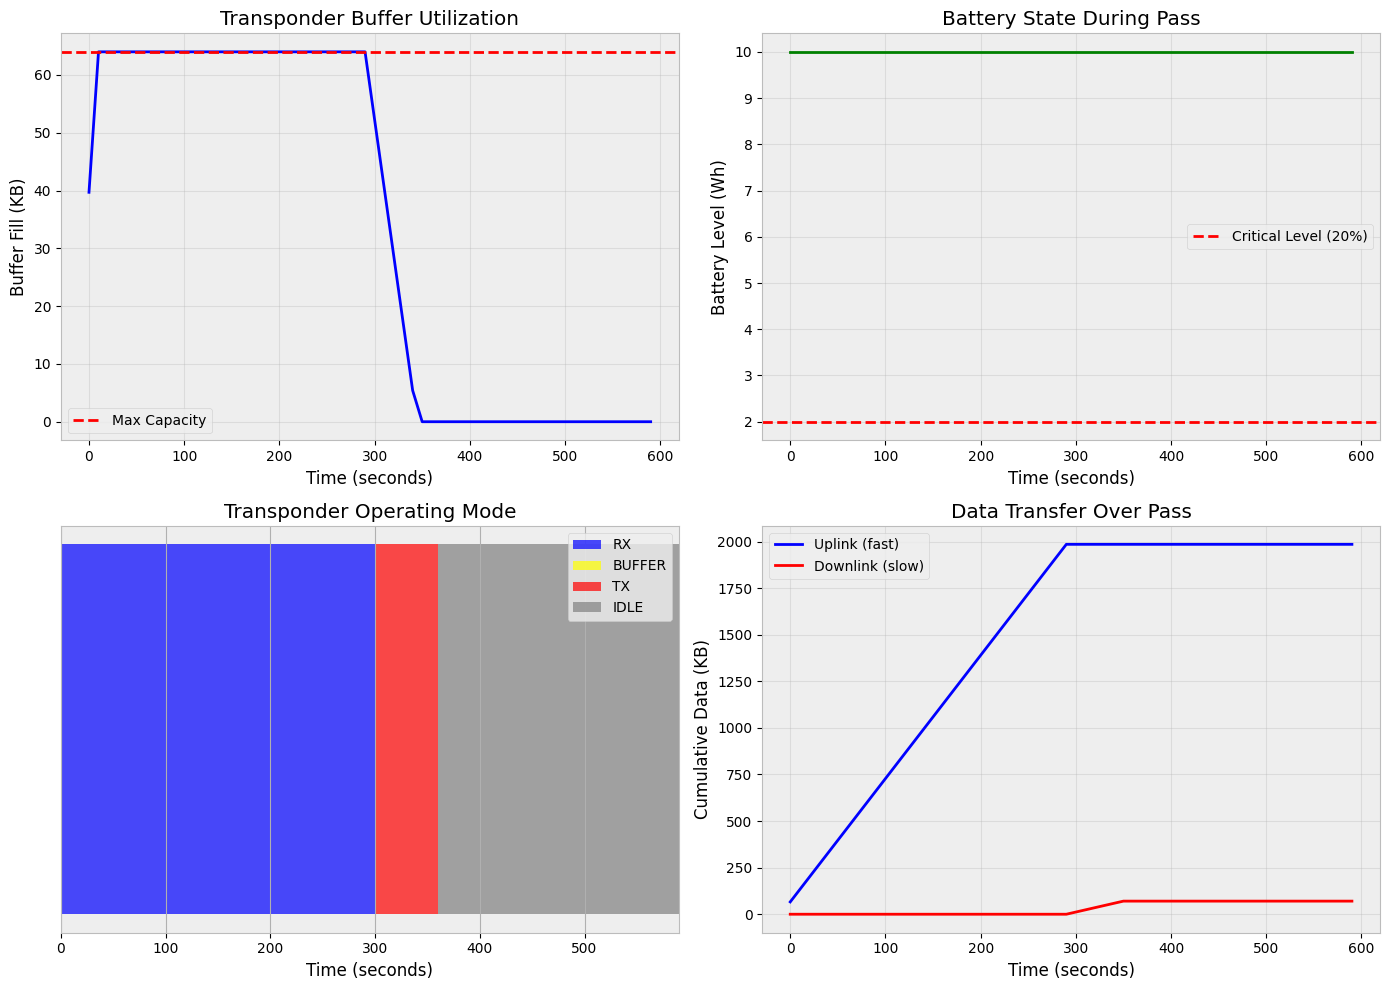

In [12]:
# Visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))

time_axis = np.arange(len(transponder.buffer_history)) * 10

# Buffer fill over time
ax1.plot(time_axis, np.array(transponder.buffer_history) / 1024, 'b-', linewidth=2)
ax1.set_xlabel('Time (seconds)')
ax1.set_ylabel('Buffer Fill (KB)')
ax1.set_title('Transponder Buffer Utilization')
ax1.grid(True, alpha=0.3)
ax1.axhline(y=config.buffer_size_bytes/1024, color='r', linestyle='--', label='Max Capacity')
ax1.legend()

# Battery level over time
ax2.plot(time_axis, transponder.battery_history, 'g-', linewidth=2)
ax2.set_xlabel('Time (seconds)')
ax2.set_ylabel('Battery Level (Wh)')
ax2.set_title('Battery State During Pass')
ax2.grid(True, alpha=0.3)
ax2.axhline(y=config.battery_capacity_wh * 0.2, color='r', linestyle='--', label='Critical Level (20%)')
ax2.legend()

# Mode timeline
mode_colors = {1: 'blue', 2: 'yellow', 3: 'red', 4: 'gray'}
mode_names = {1: 'RX', 2: 'BUFFER', 3: 'TX', 4: 'IDLE'}
for i, current_mode in enumerate(transponder.mode_history):
    ax3.barh(0, 10, left=i*10, color=mode_colors[current_mode], alpha=0.7, height=0.5)
ax3.set_xlabel('Time (seconds)')
ax3.set_yticks([])
ax3.set_title('Transponder Operating Mode')
ax3.set_xlim(0, max(time_axis))

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color, alpha=0.7, label=mode_names[mode_id]) for mode_id, color in mode_colors.items()]
ax3.legend(handles=legend_elements, loc='upper right');

# Data flow rates
cumulative_rx = np.cumsum([transponder.config.uplink_rate_bps / 8 * 10 if m == 1 else 0 for m in transponder.mode_history]) / 1024
cumulative_tx = np.cumsum([transponder.config.downlink_rate_bps / 8 * 10 if m == 3 else 0 for m in transponder.mode_history]) / 1024
ax4.plot(time_axis, cumulative_rx, 'b-', linewidth=2, label='Uplink (fast)')
ax4.plot(time_axis, cumulative_tx, 'r-', linewidth=2, label='Downlink (slow)')
ax4.set_xlabel('Time (seconds)')
ax4.set_ylabel('Cumulative Data (KB)')
ax4.set_title('Data Transfer Over Pass')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()

# Save to current directory instead
plt.savefig('funcube_plus_simulation.png', dpi=150)
print("\n✓ Simulation plot saved to current directory")
plt.show()

# Part II: Modeling the May 2026 Variant of MDT

The model above treats the MDT as a single-stream rate-asymmetric digital relay: one fast uplink, one slow downlink, a buffer between them. That is the framing ORI engaged with when AMSAT-UK first invited collaboration on FunCube+.

In May 2026, David Bowman circulated a discussion document (`MDT_Discussion_doc.docx`, 11 May 2026) describing a different architecture for MDT, which is the original 2023 colloquium concept restated:

- A **multi-user uplink**: roughly 10 kHz of receiver bandwidth, accepting up to ~10 simultaneous 1200 bps BPSK signals from different ground stations during a 7.5-second receive window.
- **On-board demodulation, CRC validation, deduplication, and reformatting** of each received packet.
- A **parallel FDMA downlink**: N simultaneous narrowband signals (~250 bps BPSK with FEC, or FT4-style ~100 Hz wide), each on an MDT-chosen frequency at equal power, transmitted in a ~6-second window.
- A **repeating cycle** of RX -> process -> parallel TX -> guard, on the order of 7.5 + 1 + 6 + 0.5 = 15 seconds.

This is structurally different from the single-stream model in Part I, so the analysis in Part I does not address it. Several aspects of the proposal are not adequately analyzed in the discussion document itself:

1. **The on-board demodulator bank.** Demodulating up to 10 simultaneous 1200 bps BPSK signals on-board is not free. It requires a channelizer plus N demodulators, each with timing recovery, AFC, and frame sync. That cost has to fit inside the FPGA budget.
2. **The downlink PA back-off penalty.** Generating N simultaneous narrowband carriers from the *one* satellite downlink PA is not equivalent to N independent 50 mW transmitters. The peak-to-average power ratio (PAPR) of the composite signal grows with N, and a linear PA must be backed off to avoid distortion. This eats into the per-carrier effective output power. The uplink PAs do not pay this penalty. They are independent ground-station transmitters, each handling one BPSK signal at near-constant envelope. The uplink's analogous concern is Doppler spread across simultaneous users, item 3 below.
3. **Doppler spread across simultaneous users.** Ground stations distributed across the satellite footprint see different line-of-sight velocities. For a 10 kHz wideband receiver at 70 cm, the Doppler spread between two stations near opposite horizons can exceed the receiver bandwidth.
4. **The "halve the rate, save the power" intuition.** Reducing bit rate reduces bandwidth, which reduces received noise power N = kTB. That buys range or SNR margin. It does *not*, by itself, save transmitter energy per bit at constant PA efficiency. The two effects are easy to conflate.

This section builds a domain model for the May 2026 variant, computes each of these effects, and presents the results so they can be evaluated on their merits. The values that come from clear physics (Doppler, kTB, PAPR statistics) are computed directly. Values that depend on implementation choice (per-demodulator LUT cost, PA class and back-off curve) are exposed as parameters with stated assumptions and swept across plausible ranges.

> **Note on data provenance.** Numbers in the cells below are either (a) computed from first principles, (b) taken directly from David's discussion document, or (c) parameterized estimates with explicitly labeled assumptions. Where an assumption is made, it is called out. Synthesis-derived numbers from the `mdt_sic` build are not substituted in; those need to come from real reports.


## Domain model

In the single-stream model the entities were straightforward: one TransponderConfig, one DynamicTransponder, time-asymmetric rates. The May 2026 variant introduces new entities that the original model does not represent:

| Entity | What it represents |
|---|---|
| `MDT2026Config` | All parameters of the May 2026 variant: cycle timing, channel counts, link parameters, processing assumptions. |
| `UplinkPacket` | A single 1200 bps BPSK transmission from one ground station, with content, Doppler offset, and validity flags (CRC, duplicate). |
| `DownlinkSlot` | A frequency assignment + power budget for one parallel downlink signal, plus its modulation parameters. |
| `Cycle` | The repeating RX/process/TX/guard frame, computed from the timing parameters. |

The single-stream model in Part I is *not deleted*. It remains valid as a coarse rate/buffer/power sanity check, and we will reuse some of its scaffolding. The new model adds the multi-user, FDMA, cyclical, and resource-cost dimensions that the May 2026 variant requires.

It is helpful to think of this the way a D&D group would think about turning a single solo encounter into a parallel skirmish across multiple zones. The dungeon (the satellite payload) is the same. The combat math (link budget) is mostly the same per combatant. But you now need initiative order across multiple zones, shared resource pools (the PA, the FPGA's LUTs), and you have to track each combatant's individual state. The bookkeeping is what changes.


In [13]:
@dataclass
class MDT2026Config:
    """May 2026 Bowman variant of MDT (multi-user channelized FDMA store-and-forward).

    All values come directly from MDT_Discussion_doc.docx (11 May 2026) unless
    marked as an assumption. Assumption-derived defaults are clearly labeled
    in comments next to each field.
    """
    # --- From discussion document (directly specified) ---
    uplink_rate_bps_per_user: int = 1200          # 1200 bps BPSK uplink
    uplink_bandwidth_per_user_hz: float = 1500.0  # ~1.5 kHz for filtered 1200 bps BPSK
                                                  # (ASSUMPTION: 1.25x symbol rate occupancy)
    uplink_receiver_bandwidth_hz: float = 10_000  # 10 kHz "slice of spectrum"
    uplink_packet_duration_sec: float = 2.0       # "not exceeding 2 seconds"
    max_simultaneous_uplink_users: int = 10       # "perhaps 10 or more"
    rx_window_sec: float = 7.5                    # 7.5 s receive period
    tx_window_sec: float = 6.0                    # "completed within the next 6 seconds"

    downlink_rate_bps_per_user: int = 250         # 250 bps with FEC (BPSK option)
    downlink_bandwidth_per_user_hz: float = 100.0 # FT4-style 100 Hz per signal
    downlink_carrier_spacing_hz: float = 100.0    # 100 Hz between signals
    downlink_total_users: int = 10                # 10 stations sharing 500 mW

    pa_nominal_output_watts: float = 0.5          # 500 mW satellite PA
    downlink_freq_hz: float = 145.9e6             # 2 m band (per AO-73 reference)
    uplink_freq_hz: float = 435.15e6              # 70 cm band (per AO-73 reference)

    # --- Assumptions (NOT in the discussion document) ---
    fpga_total_luts: int = 5280                   # iCE40UP5K hard spec from Lattice
    fpga_luts_already_committed: int = 3000       # ASSUMPTION: channelizer + glue logic baseline
                                                  # (verify against actual mdt_sic synthesis report)
    per_demod_lut_cost_min: int = 200             # ASSUMPTION: minimal CIC + Gardner TED demod
    per_demod_lut_cost_max: int = 2000            # ASSUMPTION: full coherent demod w/ AFC, frame sync, CRC

    pa_efficiency_at_saturation: float = 0.50     # ASSUMPTION: ~50% PAE at full saturation
    orbit_altitude_km: float = 580                # Falcon 9 rideshare typical (per doc)


### Reading the config

Two things are worth noting about this dataclass.

First, *every* field is annotated with where it came from. The values pulled directly from David's document are intentionally not modified - including ones that are arguably optimistic (the 500 mW total PA output, the 10 simultaneous users in 10 kHz). The point of the model is to evaluate the proposal *as written*. If we silently substituted different numbers, the analysis would not be a critique of the proposal. It would be a critique of an imagined version of it, and that is not what we're about. 

Second, the *assumptions* are labeled as assumptions. The per-demodulator LUT cost is a range, not a single number, because the real cost depends on architectural choices (coherent vs. non-coherent, presence of AFC, FEC inside or outside the demod, etc.) that David's document does not specify. Likewise the PA back-off model is a generic class-AB approximation. A Doherty or envelope-tracking PA would do better, but those are uncommon at CubeSat power and mass budgets.

Where a real synthesis report from the `mdt_sic` build is available, the `fpga_luts_already_committed` value should be replaced with the verified number. It is flagged here so it is not forgotten.


In [14]:
@dataclass
class UplinkPacket:
    """A single packet from one ground station during the RX window."""
    station_id: int
    duration_sec: float
    payload_bytes: int
    crc_ok: bool
    is_duplicate: bool
    doppler_hz: float           # line-of-sight Doppler at this station, this instant
    snr_db_at_satellite: float  # post-channelizer, pre-demod estimate

    @property
    def is_valid(self) -> bool:
        """A packet is 'valid' if CRC passes and it is not a duplicate."""
        return self.crc_ok and not self.is_duplicate


@dataclass
class DownlinkSlot:
    """One assigned downlink frequency and the parameters used for it."""
    slot_id: int
    frequency_hz: float          # absolute frequency for this slot
    rate_bps: int                # bit rate inside the slot
    bandwidth_hz: float          # occupied bandwidth (Hz)
    power_watts: float           # per-slot transmit power (after PA back-off)
    payload_bytes: int           # bytes carried in this slot during the TX window


## Cycle timing - does the proposed cycle actually close?

David's document gives these timing values:

- RX window: 7.5 s
- TX window: ends by T = 6.5 s of the next cycle, started at T = 0.5 s, so TX duration ~ 6.0 s
- Guard / decode time after TX: ~1 s

If RX, processing, and TX all run sequentially within a single cycle, the timing has to close. The cell below confirms whether it does.

This matters because David also implies the cycle *repeats* - RX again immediately after the post-TX guard. If processing slips into the next RX window, packets get lost.


In [15]:
def check_cycle_timing(cfg, processing_sec=1.0, guard_sec=0.5):
    """Check whether RX + processing + TX + guard fits in one cycle."""
    total = cfg.rx_window_sec + processing_sec + cfg.tx_window_sec + guard_sec
    print(f"  RX window:           {cfg.rx_window_sec:5.2f} s")
    print(f"  Processing (assumed):{processing_sec:5.2f} s   <-- ASSUMPTION, not in doc")
    print(f"  TX window:           {cfg.tx_window_sec:5.2f} s")
    print(f"  Guard (assumed):     {guard_sec:5.2f} s   <-- ASSUMPTION, not in doc")
    print(f"  ---")
    print(f"  Total cycle:         {total:5.2f} s")
    print()
    if total <= 15.0:
        print(f"  Cycle closes in {total:.2f} s. Margin to a 15 s frame: {15-total:.2f} s.")
    else:
        print(f"  Cycle does NOT close in 15 s. Processing/guard assumptions need to shrink.")
    return total

cfg_2026 = MDT2026Config()
_ = check_cycle_timing(cfg_2026)


  RX window:            7.50 s
  Processing (assumed): 1.00 s   <-- ASSUMPTION, not in doc
  TX window:            6.00 s
  Guard (assumed):      0.50 s   <-- ASSUMPTION, not in doc
  ---
  Total cycle:         15.00 s

  Cycle closes in 15.00 s. Margin to a 15 s frame: 0.00 s.


## On-board demodulator resource budget

David's document says the satellite will accept "perhaps 10 or more" simultaneous 1200 bps BPSK signals in 10 kHz of receiver bandwidth, and that the on-board signal "is demodulated on board." It does not analyze what that costs in FPGA resources.

The cost has two parts:

1. A **channelizer** that splits 10 kHz of input spectrum into per-channel basebands. A polyphase channelizer is the standard approach. There is one channelizer regardless of how many users are present.
2. **N demodulators**, one per active user, each handling timing recovery, AFC, frame sync, and CRC. The demodulator count scales with the user count.

The channelizer is largely fixed cost; we lump it into `fpga_luts_already_committed`. The variable cost is the demodulators.

Since the per-demodulator cost depends on implementation choices that David's document does not specify (coherent vs. differential, with or without FEC, soft vs. hard frame sync), we sweep over a plausible range and show the feasibility envelope. The point of the plot is to show *how sensitive* the multi-user claim is to demodulator implementation cost - not to assert a single number.


In [16]:
def demod_feasibility_sweep(cfg):
    """For each plausible per-demod LUT cost, compute how many demods fit."""
    luts_available = cfg.fpga_total_luts - cfg.fpga_luts_already_committed
    per_demod = np.arange(cfg.per_demod_lut_cost_min,
                          cfg.per_demod_lut_cost_max + 1, 50)
    demods_fittable = np.floor(luts_available / per_demod).astype(int)
    return per_demod, demods_fittable, luts_available

per_demod_lut, n_demods, lut_budget = demod_feasibility_sweep(cfg_2026)
print(f"  iCE40UP5K total LUTs:                   {cfg_2026.fpga_total_luts}")
print(f"  Committed to channelizer + glue (est.): {cfg_2026.fpga_luts_already_committed}  [ASSUMPTION]")
print(f"  Remaining LUT budget for demods:        {lut_budget}")
print(f"  David's target users:                   {cfg_2026.max_simultaneous_uplink_users}")
print()
print("  Per-demod LUT cost  | Demods that fit")
print("  ------------------- | ---------------")
for c, n in zip(per_demod_lut[::4], n_demods[::4]):
    flag = " <-- fits 10 users" if n >= 10 else ""
    print(f"       {c:5d}          |    {n:5d}   {flag}")


  iCE40UP5K total LUTs:                   5280
  Committed to channelizer + glue (est.): 3000  [ASSUMPTION]
  Remaining LUT budget for demods:        2280
  David's target users:                   10

  Per-demod LUT cost  | Demods that fit
  ------------------- | ---------------
         200          |       11    <-- fits 10 users
         400          |        5   
         600          |        3   
         800          |        2   
        1000          |        2   
        1200          |        1   
        1400          |        1   
        1600          |        1   
        1800          |        1   
        2000          |        1   


## Downlink PA back-off for N parallel narrowband carriers

This applies specifically to the **downlink** PA on the satellite, where one PA produces all N carriers simultaneously. The uplink PAs are independent ground-station transmitters, each handling a single BPSK signal at near-constant envelope, and do not see this penalty.

A PA is typically rated by its output power at saturation. For a constant-envelope signal (single-tone, FM, MSK, GMSK), the average output power equals saturation power and PA efficiency is at its best.

For N simultaneous narrowband carriers added together at the PA input, the composite envelope is **not** constant. With N carriers of equal amplitude at uncorrelated phases:

- Worst-case (all carriers momentarily in phase): peak envelope = N * single-tone amplitude, so peak power = N^2 * single-tone power, giving PAPR = 2N (about 13 dB at N=10).
- Typical (random phases, large N): the envelope is approximately Rayleigh-distributed, and PAPR has a median around 8 dB and a 99th-percentile around 11 dB at N=10. This was verified by envelope simulation.

A linear PA driven into compression will distort and spray intermodulation products into adjacent channels. To keep the multi-carrier signal clean, the PA must be backed off from saturation by approximately the PAPR. That back-off reduces *average* output power - which is what each user actually sees.

David's discussion document treats the 500 mW PA output as if it can be cleanly divided into 10 x 50 mW. That assumption requires either (a) a PA rated at peak-envelope power 5 W (10x the nominal 500 mW average) or (b) accepting substantial intermodulation distortion.


In [17]:
def pa_backoff_analysis(cfg, n_carriers_range=range(1, 17)):
    '''Compute typical and worst-case PAPR and effective per-carrier output power vs. N.

    Median PAPR values (random phases) come from envelope simulation:
        N=1:  3.0 dB    N=8:  7.6 dB
        N=2:  5.7 dB    N=10: 7.9 dB
        N=4:  6.5 dB    N=12: 7.9 dB
        N=6:  7.1 dB    N=16: 8.6 dB
    99th-percentile PAPR (random phases): ~11 dB at N=10.
    Worst-case (all-coherent): 10*log10(2N) dB.
    '''
    median_papr_data = {1: 3.0, 2: 5.7, 4: 6.5, 6: 7.1, 8: 7.6, 10: 7.9, 12: 7.9, 16: 8.6}
    median_papr = []
    worst_case_papr = []
    for N in n_carriers_range:
        if N in median_papr_data:
            m = median_papr_data[N]
        else:
            m = 3.0 + 5.0 * np.log10(max(N, 1))
        median_papr.append(m)
        worst_case_papr.append(10 * np.log10(2 * N))

    median_papr = np.array(median_papr)
    worst_case_papr = np.array(worst_case_papr)

    # Assumption: PA must be backed off by ~PAPR(dB) to avoid distortion.
    # Average output power = sat_power / 10^(PAPR/10).
    p_total_avg_typical = cfg.pa_nominal_output_watts / (10 ** (median_papr / 10))
    p_per_carrier_typical = p_total_avg_typical / np.array(list(n_carriers_range))

    p_per_carrier_david = cfg.pa_nominal_output_watts / np.array(list(n_carriers_range))

    return {
        "N": np.array(list(n_carriers_range)),
        "median_papr_db": median_papr,
        "worst_case_papr_db": worst_case_papr,
        "p_per_carrier_typical_mW": p_per_carrier_typical * 1000,
        "p_per_carrier_david_mW": p_per_carrier_david * 1000,
    }

pa_results = pa_backoff_analysis(cfg_2026)
print("  N  | Median PAPR | Worst PAPR | Per-carrier (David) | Per-carrier (typical, backed off)")
print("  ---+-------------+------------+---------------------+----------------------------------")
for i, N in enumerate(pa_results["N"]):
    if N in (1, 2, 4, 6, 8, 10, 12, 16):
        m_papr = pa_results["median_papr_db"][i]
        w_papr = pa_results["worst_case_papr_db"][i]
        p_d    = pa_results["p_per_carrier_david_mW"][i]
        p_t    = pa_results["p_per_carrier_typical_mW"][i]
        print(f"  {N:2d} |   {m_papr:5.2f} dB  |  {w_papr:5.2f} dB  |      {p_d:6.1f} mW       |          {p_t:6.2f} mW")
print()
p_d10 = pa_results["p_per_carrier_david_mW"][9]
p_t10 = pa_results["p_per_carrier_typical_mW"][9]
shortfall_db = 10 * np.log10(p_d10 / p_t10)
print(f"  At N=10, David's per-carrier goal of 50 mW assumes the 500 mW PA can deliver")
print(f"  500 mW AVERAGE across all carriers. After ~8 dB back-off for typical PAPR,")
print(f"  the actual average per-carrier output drops to ~{p_t10:.1f} mW.")
print(f"  That is a {shortfall_db:.1f} dB shortfall vs. the goal.")


  N  | Median PAPR | Worst PAPR | Per-carrier (David) | Per-carrier (typical, backed off)
  ---+-------------+------------+---------------------+----------------------------------
   1 |    3.00 dB  |   3.01 dB  |       500.0 mW       |          250.59 mW
   2 |    5.70 dB  |   6.02 dB  |       250.0 mW       |           67.29 mW
   4 |    6.50 dB  |   9.03 dB  |       125.0 mW       |           27.98 mW
   6 |    7.10 dB  |  10.79 dB  |        83.3 mW       |           16.25 mW
   8 |    7.60 dB  |  12.04 dB  |        62.5 mW       |           10.86 mW
  10 |    7.90 dB  |  13.01 dB  |        50.0 mW       |            8.11 mW
  12 |    7.90 dB  |  13.80 dB  |        41.7 mW       |            6.76 mW
  16 |    8.60 dB  |  15.05 dB  |        31.2 mW       |            4.31 mW

  At N=10, David's per-carrier goal of 50 mW assumes the 500 mW PA can deliver
  500 mW AVERAGE across all carriers. After ~8 dB back-off for typical PAPR,
  the actual average per-carrier output drops to ~8.1 m

## Doppler spread across simultaneous uplink users

The uplink receiver is described as a 10 kHz "slice of spectrum" accepting up to 10 simultaneous 1200 bps BPSK signals from ground stations distributed across the satellite footprint.

At 580 km LEO and 435 MHz (David's uplink band), the worst-case line-of-sight Doppler shift between satellite and a single ground station is about +/- 10 kHz. Two ground stations on opposite limbs of the footprint at a single instant can have line-of-sight Doppler offsets that differ by up to about 20 kHz.

This is a problem at three levels:

1. **The 10 kHz receiver passband does not contain the full Doppler spread.** A station with a Doppler offset that places its signal outside the receiver's instantaneous passband cannot be received.
2. **Ground stations are expected to pre-correct Doppler** on the uplink (standard practice for AMSAT FT4/FT8 operation), but pre-correction accuracy is limited by orbit prediction quality and station clocks. Residual error of a few hundred Hz is normal. Across 10 stations, residuals do not align, and frequency planning at the satellite must allow for that spread.
3. **The on-board demodulator AFC** must track per-channel residual offsets in real time. This is included in the per-demod LUT cost above, but the AFC search range needs to be specified.

The cell below computes Doppler for a 580 km circular LEO at the uplink and downlink frequencies and shows the worst-case spread.


In [18]:
def doppler_analysis(cfg):
    '''Compute LEO Doppler magnitudes and inter-station spread.

    Assumes a circular orbit at cfg.orbit_altitude_km altitude.
    Uses simple orbital mechanics; no oblateness, no atmospheric drag.
    '''
    c = 3e8
    mu = 398_600.4418e9   # GM_Earth, m^3/s^2
    R_e = 6_378e3         # Earth radius, m
    r = R_e + cfg.orbit_altitude_km * 1e3
    v_orb = np.sqrt(mu / r)
    # Maximum line-of-sight velocity occurs near the horizon (geometric limit)
    v_los_max = v_orb * R_e / r

    results = {}
    for band, f in [("uplink (70 cm)", cfg.uplink_freq_hz),
                    ("downlink (2 m)", cfg.downlink_freq_hz)]:
        fd_max = f * v_los_max / c
        spread = 2 * fd_max
        results[band] = {
            "f_carrier_MHz": f / 1e6,
            "doppler_max_Hz": fd_max,
            "spread_max_Hz": spread,
        }
    return results, v_orb, v_los_max

dop, v_orb, v_los_max = doppler_analysis(cfg_2026)
print(f"  Orbit altitude:                 {cfg_2026.orbit_altitude_km} km")
print(f"  Orbital velocity:               {v_orb:.0f} m/s")
print(f"  Max LOS velocity (geometric):   {v_los_max:.0f} m/s")
print()
for band, r in dop.items():
    print(f"  {band} @ {r['f_carrier_MHz']:.1f} MHz")
    print(f"     worst-case Doppler:       +/- {r['doppler_max_Hz']:.0f} Hz")
    print(f"     spread between two stations on opposite limbs: ~{r['spread_max_Hz']/1e3:.1f} kHz")
    print()

print(f"  Uplink receiver passband (per discussion doc): {cfg_2026.uplink_receiver_bandwidth_hz/1e3:.0f} kHz")
uplink_spread = dop["uplink (70 cm)"]["spread_max_Hz"]
if uplink_spread > cfg_2026.uplink_receiver_bandwidth_hz:
    print(f"  WORST-CASE Doppler spread ({uplink_spread/1e3:.1f} kHz) exceeds receiver bandwidth.")
    print(f"  This means uncorrected uplinks at the limb cannot all fit in the passband")
    print(f"  simultaneously. Pre-correction at the ground is mandatory, not optional.")


  Orbit altitude:                 580 km
  Orbital velocity:               7569 m/s
  Max LOS velocity (geometric):   6938 m/s

  uplink (70 cm) @ 435.1 MHz
     worst-case Doppler:       +/- 10063 Hz
     spread between two stations on opposite limbs: ~20.1 kHz

  downlink (2 m) @ 145.9 MHz
     worst-case Doppler:       +/- 3374 Hz
     spread between two stations on opposite limbs: ~6.7 kHz

  Uplink receiver passband (per discussion doc): 10 kHz
  WORST-CASE Doppler spread (20.1 kHz) exceeds receiver bandwidth.
  This means uncorrected uplinks at the limb cannot all fit in the passband
  simultaneously. Pre-correction at the ground is mandatory, not optional.


## What halving the bit rate actually buys (kTB clarification)

David's document derives, correctly, that thermal noise power is N = kTB and that reducing receiver bandwidth B reduces N. It then concludes that reducing the downlink data rate from 1200 bps to 300 bps gives 6 dB of SNR margin, extending AO-73-style coverage from 1500 km to 3000 km. That part of the argument is sound.

What is less clear is the implicit claim that lower bit rate "saves power" for the satellite. It does not, at first order, save transmitter energy per bit:

- Constant-envelope BPSK at 1200 bps for 1 second at 500 mW: 0.5 J of transmitter energy.
- Constant-envelope BPSK at 250 bps requires the same 500 mW PA, but to send the same payload takes ~5x longer: 2.4 J.

The benefit of the lower rate is **range / link margin**, not power. The same payload, at lower rate, can be received over a longer path or at a lower elevation. The PA still burns the same DC.

There is a *secondary* power benefit: if the lower rate occupies less of the 7.5-second TX window, the PA can be powered down for the remainder, reducing average DC draw. That is the duty-cycle benefit - and it is real - but it has to be argued as a duty-cycle argument, not a rate argument.

The cell below shows the energy and range trade-offs explicitly.


In [19]:
def downlink_tradeoff(cfg):
    '''Compare power and range across downlink rates.

    Reference: AO-73 at 40 mW BPSK 1200 bps reaches ~1500 km (per discussion doc).
    Per-bit Eb/N0 is held constant, so a rate reduction translates directly into SNR
    margin and thus into range gain via free-space path loss (which goes as 1/r^2,
    so 6 dB = 2x range).
    '''
    rates = [1200, 600, 300, 250, 100, 50]
    payload_bits = 1200 * 2   # 2 second AO-73-style packet equivalent
    pa_watts = 0.04            # AO-73 low-power 40 mW reference

    print(f"  Reference: AO-73 at 40 mW, 1200 bps, ~1500 km reach")
    print()
    print(f"  Rate (bps) | TX time (s) | TX energy (J) | SNR gain vs 1200bps | Range gain (linear)")
    print(f"  -----------+-------------+---------------+---------------------+--------------------")
    for r in rates:
        tx_time = payload_bits / r
        tx_energy = pa_watts * tx_time
        snr_gain_db = 10 * np.log10(1200.0 / r)
        range_factor = 10 ** (snr_gain_db / 20)
        ref_range_km = 1500
        print(f"      {r:5d}  |    {tx_time:5.2f}    |     {tx_energy:5.2f}     |         +{snr_gain_db:4.1f} dB        |  {range_factor:4.2f}x = {ref_range_km*range_factor:.0f} km")
    print()
    print("  Lower bit rate buys RANGE, not transmitter ENERGY (at fixed PA power).")
    print("  The energy benefit comes from duty-cycling the PA off after TX completes.")
    print("  The question then becomes whether this actually happens? With this type")
    print("      of payload, are we ever reliably and consistently Done with downlinking?")

downlink_tradeoff(cfg_2026)


  Reference: AO-73 at 40 mW, 1200 bps, ~1500 km reach

  Rate (bps) | TX time (s) | TX energy (J) | SNR gain vs 1200bps | Range gain (linear)
  -----------+-------------+---------------+---------------------+--------------------
       1200  |     2.00    |      0.08     |         + 0.0 dB        |  1.00x = 1500 km
        600  |     4.00    |      0.16     |         + 3.0 dB        |  1.41x = 2121 km
        300  |     8.00    |      0.32     |         + 6.0 dB        |  2.00x = 3000 km
        250  |     9.60    |      0.38     |         + 6.8 dB        |  2.19x = 3286 km
        100  |    24.00    |      0.96     |         +10.8 dB        |  3.46x = 5196 km
         50  |    48.00    |      1.92     |         +13.8 dB        |  4.90x = 7348 km

  Lower bit rate buys RANGE, not transmitter ENERGY (at fixed PA power).
  The energy benefit comes from duty-cycling the PA off after TX completes.
  The question then becomes whether this actually happens? With this type
      of payload, a

## Combined feasibility visualization

The four analyses above each touch one part of the May 2026 variant. Put together they sketch the feasibility envelope. Whether the on-board demod count can be hit, whether the per-carrier downlink power claim survives PAPR back-off, whether Doppler can be handled in the proposed receiver bandwidth, and what the rate/range trade actually buys.

The 2x2 plot below is the dashboard.


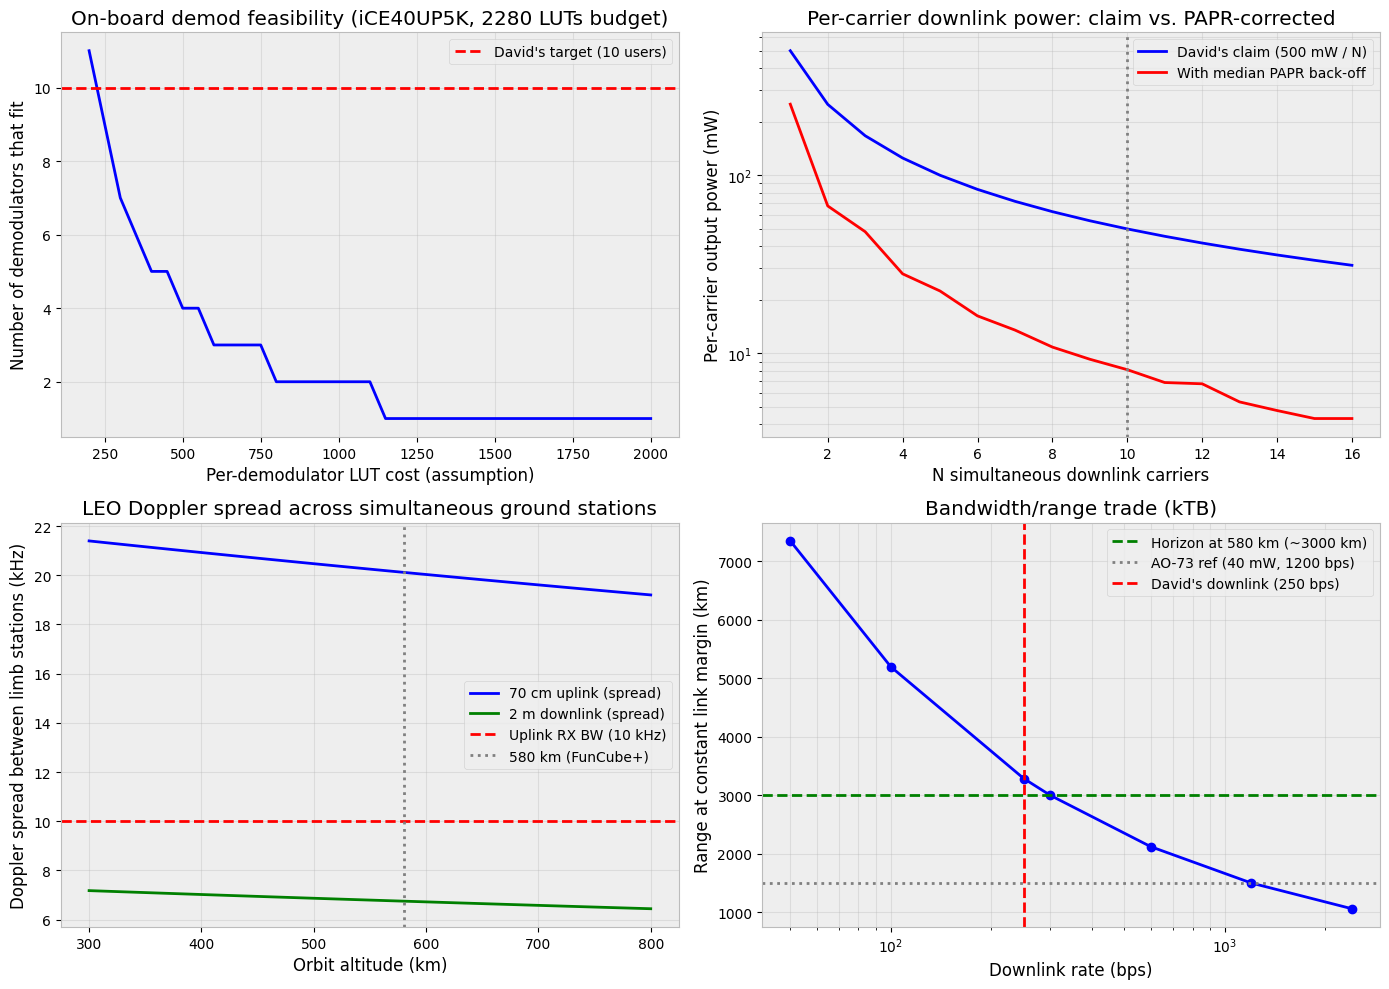

In [20]:
fig2, ((bx1, bx2), (bx3, bx4)) = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Demod feasibility envelope
per_demod_lut, n_demods, lut_budget = demod_feasibility_sweep(cfg_2026)
bx1.plot(per_demod_lut, n_demods, 'b-', linewidth=2)
bx1.axhline(y=cfg_2026.max_simultaneous_uplink_users, color='r', linestyle='--',
            label=f"David's target ({cfg_2026.max_simultaneous_uplink_users} users)")
bx1.set_xlabel('Per-demodulator LUT cost (assumption)')
bx1.set_ylabel('Number of demodulators that fit')
bx1.set_title(f'On-board demod feasibility (iCE40UP5K, {lut_budget} LUTs budget)')
bx1.grid(True, alpha=0.3)
bx1.legend()

# Plot 2: PA back-off and per-carrier power
pa_results = pa_backoff_analysis(cfg_2026, n_carriers_range=range(1, 17))
bx2.plot(pa_results['N'], pa_results['p_per_carrier_david_mW'], 'b-', linewidth=2,
         label="David's claim (500 mW / N)")
bx2.plot(pa_results['N'], pa_results['p_per_carrier_typical_mW'], 'r-', linewidth=2,
         label='With median PAPR back-off')
bx2.set_xlabel('N simultaneous downlink carriers')
bx2.set_ylabel('Per-carrier output power (mW)')
bx2.set_title('Per-carrier downlink power: claim vs. PAPR-corrected')
bx2.set_yscale('log')
bx2.grid(True, alpha=0.3, which='both')
bx2.axvline(x=cfg_2026.downlink_total_users, color='gray', linestyle=':')
bx2.legend()

# Plot 3: Doppler vs. orbit altitude across bands
altitudes_km = np.linspace(300, 800, 50)
c = 3e8
mu = 398_600.4418e9
R_e = 6_378e3
fd_70cm = np.zeros_like(altitudes_km)
fd_2m = np.zeros_like(altitudes_km)
for i, alt in enumerate(altitudes_km):
    r = R_e + alt * 1e3
    v_orb_i = np.sqrt(mu / r)
    v_los = v_orb_i * R_e / r
    fd_70cm[i] = 435e6 * v_los / c
    fd_2m[i] = 145.9e6 * v_los / c
bx3.plot(altitudes_km, 2*fd_70cm/1e3, 'b-', linewidth=2, label='70 cm uplink (spread)')
bx3.plot(altitudes_km, 2*fd_2m/1e3, 'g-', linewidth=2, label='2 m downlink (spread)')
bx3.axhline(y=cfg_2026.uplink_receiver_bandwidth_hz/1e3, color='r', linestyle='--',
            label=f'Uplink RX BW ({cfg_2026.uplink_receiver_bandwidth_hz/1e3:.0f} kHz)')
bx3.axvline(x=cfg_2026.orbit_altitude_km, color='gray', linestyle=':',
            label=f'{cfg_2026.orbit_altitude_km} km (FunCube+)')
bx3.set_xlabel('Orbit altitude (km)')
bx3.set_ylabel('Doppler spread between limb stations (kHz)')
bx3.set_title('LEO Doppler spread across simultaneous ground stations')
bx3.grid(True, alpha=0.3)
bx3.legend()

# Plot 4: Rate vs. range trade-off
rates = np.array([50, 100, 250, 300, 600, 1200, 2400])
ranges = 1500 * np.sqrt(1200.0 / rates)
bx4.plot(rates, ranges, 'b-o', linewidth=2)
bx4.axhline(y=3000, color='g', linestyle='--', label='Horizon at 580 km (~3000 km)')
bx4.axhline(y=1500, color='gray', linestyle=':', label='AO-73 ref (40 mW, 1200 bps)')
bx4.axvline(x=250, color='r', linestyle='--', label="David's downlink (250 bps)")
bx4.set_xlabel('Downlink rate (bps)')
bx4.set_ylabel('Range at constant link margin (km)')
bx4.set_xscale('log')
bx4.set_title('Bandwidth/range trade (kTB)')
bx4.grid(True, alpha=0.3, which='both')
bx4.legend()

plt.tight_layout()
plt.savefig('mdt_2026_variant_analysis.png', dpi=150)
plt.show()


## Summary and open questions

The four analyses give a coherent picture of the May 2026 variant. None of them is by itself disqualifying, but together they show that the proposal as written relies on a set of assumptions that are not in the document.

**Where the variant closes:**

- *Cycle timing.* The RX/process/TX/guard frame fits comfortably in a 15-second cycle with reasonable assumptions for processing and guard intervals.
- *kTB range gain.* Reducing downlink rate from 1200 bps to 250 bps does buy ~7 dB of link margin, which is sufficient to reach horizon at 580 km. This part of the proposal is sound.
- *Buffer sizing.* At these bit rates and a 7.5 s RX window, buffer requirements are trivial - a few kB at most. This is not a constraint.

**Where the variant needs work:**

- *On-board demod count.* Whether 10 demodulators fit on the iCE40UP5K depends entirely on per-demod LUT cost, which the discussion document does not address. The feasibility plot shows that costs above ~250 LUTs per demod (a tight but possible target for a coherent BPSK demod with AFC and frame sync) cut into the user count quickly. Without a synthesis budget the "10 users" claim is unverified.
- *PA back-off.* If the PA is specified at 500 mW *average*, dividing it as 10 x 50 mW per carrier ignores PAPR back-off. The typical median PAPR at N=10 is about 8 dB, which means per-carrier average power drops to roughly 8 mW, not 50 mW. To recover David's goal, the PA needs to be rated at ~5 W peak envelope, which has cost, mass, and DC consumption implications.
- *Doppler spread.* The 10 kHz uplink receiver bandwidth is smaller than the worst-case Doppler spread (~20 kHz) at 70 cm across the satellite footprint. Ground-station Doppler pre-correction is therefore mandatory. The document does not specify the pre-correction protocol or the residual Doppler budget passed to the on-board AFC.
- *Power = rate, conflated.* The framing "halve the rate, save the power" mixes a range argument (kTB) with a power argument (duty cycle). They are separable and should be argued separately.

**Open Questions**

1. What is the verified LUT budget for the on-board demod bank? Has a per-demod synthesis number been measured for the candidate FPGA target? No, because it hasn't been previously specified, and the MDT-SIC does interference cancellation for a wide variety of signals, but doesn't decode and forward the recovered signals to the host payload. Instead, a report is made of the signal and presented as telemetry. 
2. Is the 500 mW PA spec a peak-envelope rating or an average rating? What PA class and back-off curve are assumed?
3. What ground-station Doppler pre-correction is mandated, and what residual is the on-board AFC required to absorb?
4. How does this variant relate to the work Martin Ling has been leading on MDT-SIC? Is it a replacement, a fallback, or a parallel track? 

The answer to question 4 is the one that determines what kind of project AMSAT-UK is actually proposing for FunCube+. There is substantial re-use for the polyphase filter bank and polyphase channelizer that is up and running on the MDT-SIC ICE40+STM development board set at ORI. MDT-SIC is a very different mission than the MDT described in the May 2026 discussion document. 


# Part III: FUNcube+ Carrier Board Constraints

David Bowman provided the PA3WEG ISIS PC104 AMSAT Custom PCB outline drawing
(`ISIS.PCB.002`, Rev A, 26 Apr 2011) along with the following actionable information:

- Form factor flown on **AO-73 (FUNcube-1)** and **JO-97 (JY1Sat)**.
- Available in **2, 4, or 6 PCB layers**.
- KiCad template available on request.
- Inter-board connectors: **Samtec ESQ-126-39-G-D** (52 pins each, two connectors per card).
- EPS rails: **5 V** and **3.3 V**, plus **battery at ~8.3 V** when fully charged.

This section captures the hardware platform as a dataclass and runs a few sanity checks
against both the May 2026 variant's implied requirements and the MDT-SIC build.

Every numeric field is explicitly labeled as **verified from the drawing**,
**verified from the email**, **inferred**, or **ASSUMPTION**. 


In [21]:
from dataclasses import dataclass
from typing import Tuple


@dataclass
class FUNcubePlusBoard:
    """ISIS PC104 AMSAT Custom carrier board (PA3WEG design).

    Drawing:  ISIS.PCB.002, Rev A, 26 Apr 2011
    Source:   David Bowman email + attached PDF (May 2026).
    """

    # --- VERIFIED from PA3WEG drawing ---
    pcb_outer_x_mm: float = 95.9               # outer envelope, long axis
    pcb_outer_y_mm: float = 90.9               # outer envelope, short axis
    inner_corner_radius_mm: float = 1.0

    mounting_holes: int = 4
    mounting_hole_diameter_mm: float = 3.2
    mounting_hole_keepout_diameter_mm: float = 6.4   # copper ring

    connector_part: str = "Samtec ESQ-126-39-G-D"
    connector_count: int = 2
    connector_pins_per: int = 52               # 26 positions x 2 rows
    connector_pitch_mm: float = 2.54
    connector_hole_diameter_mm: float = 1.02

    # --- VERIFIED from David's email ---
    pcb_layers_available: Tuple[int, ...] = (2, 4, 6)
    rail_3v3: bool = True
    rail_5v: bool = True
    vbat_nominal_v: float = 8.3                # fully charged

    heritage: Tuple[str, ...] = ("AO-73 FUNcube-1", "JO-97 JY1Sat")

    # --- ASSUMPTIONS pending KiCad template / pinout map ---
    # Specific cutout locations are not parsed from the dimension-only PDF;
    # the KiCad template David offered will supersede any assumed geometry.
    connector_footprint_width_mm: float = 5.0          # ASSUMPTION
    pc104_pin_power_ground_fraction: float = 0.30      # ASSUMPTION: typical
    pa_efficiency_constant_env: float = 0.40           # ASSUMPTION: Class-AB typical
    pa_efficiency_backed_off: float = 0.15             # ASSUMPTION: after ~8 dB back-off


board = FUNcubePlusBoard()
print(board)


FUNcubePlusBoard(pcb_outer_x_mm=95.9, pcb_outer_y_mm=90.9, inner_corner_radius_mm=1.0, mounting_holes=4, mounting_hole_diameter_mm=3.2, mounting_hole_keepout_diameter_mm=6.4, connector_part='Samtec ESQ-126-39-G-D', connector_count=2, connector_pins_per=52, connector_pitch_mm=2.54, connector_hole_diameter_mm=1.02, pcb_layers_available=(2, 4, 6), rail_3v3=True, rail_5v=True, vbat_nominal_v=8.3, heritage=('AO-73 FUNcube-1', 'JO-97 JY1Sat'), connector_footprint_width_mm=5.0, pc104_pin_power_ground_fraction=0.3, pa_efficiency_constant_env=0.4, pa_efficiency_backed_off=0.15)


## Usable PCB area

Outer envelope is 95.9 mm × 90.9 mm ≈ 87.2 cm². Mounting-hole copper-ring keepouts
and the two stack-through connectors remove area. The AMSAT Custom variant has
additional cutouts visible on the drawing — those geometries are **not** parsed from
the bare-dimension PDF and will be taken from the KiCad template when it arrives.

This is a rough envelope, not a routing study.


In [22]:
import math

outer_area_mm2 = board.pcb_outer_x_mm * board.pcb_outer_y_mm

keepout_area_mm2 = (
    board.mounting_holes
    * math.pi
    * (board.mounting_hole_keepout_diameter_mm / 2) ** 2
)

connector_length_mm = 26 * board.connector_pitch_mm   # 26 positions
connector_area_mm2 = (
    board.connector_count
    * connector_length_mm
    * board.connector_footprint_width_mm
)

usable_area_mm2 = outer_area_mm2 - keepout_area_mm2 - connector_area_mm2

print(f"Outer envelope:                          {outer_area_mm2:8.1f} mm²  "
      f"({outer_area_mm2/100:.2f} cm²)")
print(f"  - 4x mounting-ring keepouts:           {keepout_area_mm2:8.1f} mm²")
print(f"  - 2x connector footprints (5mm ASSUMED): {connector_area_mm2:8.1f} mm²")
print( "  -----------------------------------------------------")
print(f"Usable area (rough, no AMSAT cutouts):    {usable_area_mm2:8.1f} mm²  "
      f"({usable_area_mm2/100:.2f} cm²)")
print()
print("Note: AMSAT Custom cutouts will reduce this further once the KiCad")
print("template is in hand. Treat this as an upper bound.")


Outer envelope:                            8717.3 mm²  (87.17 cm²)
  - 4x mounting-ring keepouts:              128.7 mm²
  - 2x connector footprints (5mm ASSUMED):    660.4 mm²
  -----------------------------------------------------
Usable area (rough, no AMSAT cutouts):      7928.2 mm²  (79.28 cm²)

Note: AMSAT Custom cutouts will reduce this further once the KiCad
template is in hand. Treat this as an upper bound.


## Inter-board signal pin budget

Two ESQ-126-39-G-D connectors give **104 raw pins** between this card and the rest of
the PC104 stack. Stack conventions reserve some fraction for power, ground, and
standard bus signals (I²C, SPI, JTAG, reset, etc.). Assuming ~30% reserved — an
**ASSUMPTION** pending the PA3WEG pinout — that leaves ~73 pins for payload-specific
signaling.

Both candidate architectures are comfortably inside this budget:

- **MDT-SIC** (iCE40UP5K + STM32H7 + ADC/DAC) typically needs <40 inter-board signals.
- **May 2026 variant** as described in David's doc needs even fewer if the demods
  share one ADC bus.


In [23]:
raw_pins = board.connector_count * board.connector_pins_per
reserved_pins = int(raw_pins * board.pc104_pin_power_ground_fraction)
payload_pins = raw_pins - reserved_pins

print(f"Total inter-board pins:                  {raw_pins}")
print(f"  - reserved (30% ASSUMPTION):           {reserved_pins}")
print( "  ---------------------------------------------")
print(f"Available for payload signals:           {payload_pins}")
print()
print("Verify against actual PA3WEG H1/H2 pinout when AMSAT-UK provides it.")


Total inter-board pins:                  104
  - reserved (30% ASSUMPTION):           31
  ---------------------------------------------
Available for payload signals:           73

Verify against actual PA3WEG H1/H2 pinout when AMSAT-UK provides it.


## PA current at 8.3 V — where Part II's PAPR penalty actually bites

David's May 2026 doc specifies a 500 mW total downlink PA split across N parallel
narrowband carriers. At Vbat = 8.3 V (fully charged), the DC current draw depends
strongly on which assumption we make about the PA operating point.

The Part II PAPR analysis showed the multi-carrier downlink needs ~7.9 dB of back-off
at N=10 just to keep peaks linear. That back-off translates directly into PA
efficiency loss, which translates into bus current. This is where the multi-carrier
idea gets expensive on a CubeSat.


In [24]:
pa_rf_output_w = 0.500  # from David's doc

# Two operating-point bookends:
pa_dc_power_constant_w = pa_rf_output_w / board.pa_efficiency_constant_env
pa_dc_current_constant_a = pa_dc_power_constant_w / board.vbat_nominal_v

pa_dc_power_backed_off_w = pa_rf_output_w / board.pa_efficiency_backed_off
pa_dc_current_backed_off_a = pa_dc_power_backed_off_w / board.vbat_nominal_v

print(f"At Vbat = {board.vbat_nominal_v} V, PA RF output = {pa_rf_output_w*1000:.0f} mW:")
print()
print("  Constant-envelope reference (Class-AB @ 40% ASSUMED):")
print(f"    DC power: {pa_dc_power_constant_w*1000:6.0f} mW")
print(f"    DC current: {pa_dc_current_constant_a*1000:6.0f} mA")
print()
print("  Multi-carrier with ~8 dB PAPR back-off (Class-AB @ 15% ASSUMED):")
print(f"    DC power: {pa_dc_power_backed_off_w*1000:6.0f} mW")
print(f"    DC current: {pa_dc_current_backed_off_a*1000:6.0f} mA")
print()
print("The multi-carrier penalty more than doubles bus current for the same")
print("delivered RF power. This compounds with the per-carrier shortfall")
print("from Part II (50 mW promised -> ~8 mW actual after back-off).")
print()
print("Single-carrier or constant-envelope downlink is far more bus-friendly.")


At Vbat = 8.3 V, PA RF output = 500 mW:

  Constant-envelope reference (Class-AB @ 40% ASSUMED):
    DC power:   1250 mW
    DC current:    151 mA

  Multi-carrier with ~8 dB PAPR back-off (Class-AB @ 15% ASSUMED):
    DC power:   3333 mW
    DC current:    402 mA

The multi-carrier penalty more than doubles bus current for the same
delivered RF power. This compounds with the per-carrier shortfall
from Part II (50 mW promised -> ~8 mW actual after back-off).

Single-carrier or constant-envelope downlink is far more bus-friendly.


## What David's hardware envelope changes

Part II ran the May 2026 variant against general LEO physics and FPGA resource
budgets. With the carrier-board constraints in hand:

- **PCB area** is constrained but not tight. Single-board MDT-SIC fits.
  Single-board David-variant fits. Both leave room for the analog frontend.
- **Inter-board pins** (~73 payload pins after stack reservation) are
  comfortably more than either architecture needs.
- **Power rails** (3.3 V, 5 V, 8.3 V Vbat) are FPGA-friendly. iCE40UP5K core (1.2 V)
  plus 3.3 V bank from the supplied 3.3 V rail is trivial. STM32H7 runs from 3.3 V.
- **PA current at 8.3 V** is the real constraint, and Part II's PAPR penalty
  compounds with PA efficiency loss. A multi-carrier downlink costs roughly
  **2.5× the bus current** of a constant-envelope downlink delivering the same
  RF power. On a CubeSat this is the kind of factor that drives architecture.

### Open questions for David (updated with hardware in hand)

1. **H1 / H2 pinout** — which pins does AMSAT-UK reserve for stack-standard signals
   (I²C, SPI, JTAG, reset, telemetry bus)? Need the map before any board layout.
2. **Vbat access** — is the ~8.3 V battery rail routed directly to payload pins,
   or does the EPS regulate it? Current-limit on that rail?
3. **PA part / heritage** — is the 500 mW figure tied to a specific PA candidate,
   or an in-progress part? AO-73's 300 mW PEP linear PEP suggests the bus can support
   higher RF, but not by much.
4. **Thermal envelope** — does the AMSAT Custom ground plane act as the PA heat
   sink, or is thermal management on the payload card?
5. **MDT-SIC** how does the May 2026 variant relate to the
   MDT-SIC work already underway? Same launch slot, complementary, or replacement? With an FPGA and a capable
   STM processor, it could be configured to swap in one or the other on orbit. This would take a lot of work
   and testing. 
